# Figure 4 Main + Supplementary Figure Builder

This notebook assumes the previous explanation-reliability analysis has already been run.

It **does not retrain Logistic Regression, Linear SVM, or XGBoost**.  
It reads saved result tables from `../results/Figure4/` and generates:

- Main Figure 4
- Supplementary Figure S4

This version is compatible with the updated false-explanation stress test using:
- Gaussian noise
- Permuted-feature controls
- Spurious proxy features


In [7]:
# ============================================================
# 0. Imports and publication settings
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

try:
    from IPython.display import display
except Exception:
    display = print

# PNAS-style sizing:
# 170 mm = 6.69 inches, close to 2-column width.
FIG_WIDTH_MM = 170
MAIN_FIG_HEIGHT_MM = 145
SUPP_FIG_HEIGHT_MM = 165

TOP_K = 20

RESULT_DIR = Path("../results/Figure4")
MAIN_FIG_DIR = Path("../figures/Figure4")
SUPP_FIG_DIR = Path("../figures/Supplementary_Figures")

MAIN_FIG_DIR.mkdir(parents=True, exist_ok=True)
SUPP_FIG_DIR.mkdir(parents=True, exist_ok=True)

MAIN_PNG = MAIN_FIG_DIR / "Figure4_explanation_reliability_170mm_from_results.png"
MAIN_PDF = MAIN_FIG_DIR / "Figure4_explanation_reliability_170mm_from_results.pdf"

SUPP_PNG = SUPP_FIG_DIR / "Supplementary_FigureS4_explanation_reliability_diagnostics_170mm.png"
SUPP_PDF = SUPP_FIG_DIR / "Supplementary_FigureS4_explanation_reliability_diagnostics_170mm.pdf"

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 7,
        "axes.titlesize": 8,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 5.8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.dpi": 600,
    }
)

print("RESULT_DIR:", RESULT_DIR.resolve())
print("MAIN_FIG_DIR:", MAIN_FIG_DIR.resolve())
print("SUPP_FIG_DIR:", SUPP_FIG_DIR.resolve())


RESULT_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4
MAIN_FIG_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\figures\Figure4
SUPP_FIG_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\figures\Supplementary_Figures


In [8]:
# ============================================================
# 1. Load saved result tables from previous analysis
# ============================================================

required_files = {
    "stability_df": RESULT_DIR / "figure4_panelA_stability.csv",
    "fer_repeats_df": RESULT_DIR / "figure4_panelB_false_explanation_rate_repeats.csv",
    "fer_summary_df": RESULT_DIR / "figure4_panelB_false_explanation_rate_summary.csv",
    "agreement_mat": RESULT_DIR / "figure4_panelC_method_agreement_jaccard.csv",
    "method_top_features_df": RESULT_DIR / "figure4_panelC_top_features_by_method.csv",
    "domain_summary_df": RESULT_DIR / "figure4_panelD_domain_composition.csv",
    "noise_top_features_df": RESULT_DIR / "figure4_noise_injection_top_features.csv",
}

missing = [str(path) for path in required_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Some Figure 4 result files are missing. "
        "Run the previous analysis notebook first.\nMissing:\n"
        + "\n".join(missing)
    )

stability_df = pd.read_csv(required_files["stability_df"])
fer_repeats_df = pd.read_csv(required_files["fer_repeats_df"])
fer_summary_df = pd.read_csv(required_files["fer_summary_df"])
agreement_mat = pd.read_csv(required_files["agreement_mat"], index_col=0)
method_top_features_df = pd.read_csv(required_files["method_top_features_df"])
domain_summary_df = pd.read_csv(required_files["domain_summary_df"])
noise_top_features_df = pd.read_csv(required_files["noise_top_features_df"])

# Backward compatibility for older result files without stress_type.
if "stress_type" not in fer_repeats_df.columns:
    fer_repeats_df["stress_type"] = "Noise injection"
if "stress_type" not in fer_summary_df.columns:
    fer_summary_df["stress_type"] = "Noise injection"
if "stress_type" not in domain_summary_df.columns:
    domain_summary_df["stress_type"] = "Noise injection"
if "stress_type" not in noise_top_features_df.columns:
    noise_top_features_df["stress_type"] = "Noise injection"

# Backward compatibility for old domain names.
domain_summary_df["domain"] = domain_summary_df["domain"].replace({"Noise": "Injected false signal"})
method_top_features_df["domain"] = method_top_features_df["domain"].replace({"Noise": "Injected false signal"})
noise_top_features_df["domain"] = noise_top_features_df["domain"].replace({"Noise": "Injected false signal"})

if "n_injected_false_signals_in_top_k" not in fer_repeats_df.columns:
    fer_repeats_df["n_injected_false_signals_in_top_k"] = fer_repeats_df.get("n_noise_in_top_k", 0)

if "mean_noise_count" not in fer_summary_df.columns:
    fer_summary_df["mean_noise_count"] = 0

if "top_k" in fer_repeats_df.columns:
    TOP_K = int(fer_repeats_df["top_k"].dropna().iloc[0])

display(stability_df)
display(fer_summary_df.head(20))
display(agreement_mat)
display(domain_summary_df.head(20))


,model,stability_mean,stability_std,n_pairwise_fold_comparisons
0,Logistic Regression,0.427602,0.076525,10
1,Linear SVM,0.427159,0.071459,10
2,XGBoost,0.416535,0.065411,10


,stress_type,model,fer_mean,fer_std,mean_noise_count
0,Gaussian noise,Linear SVM,0.0,0.0,0.0
1,Gaussian noise,Logistic Regression,0.0,0.0,0.0
2,Gaussian noise,XGBoost,0.0,0.0,0.0
3,Permuted feature,Linear SVM,0.0,0.0,0.0
4,Permuted feature,Logistic Regression,0.0,0.0,0.0
5,Permuted feature,XGBoost,0.0,0.0,0.0
6,Spurious proxy,Linear SVM,1.0,0.0,20.0
7,Spurious proxy,Logistic Regression,1.0,0.0,20.0
8,Spurious proxy,XGBoost,1.0,0.0,20.0


,LR coef.,SVM coef.,XGB gain,XGB perm.
LR coef.,1.000000,0.428571,0.081081,0.052632
SVM coef.,0.428571,1.000000,0.081081,0.025641
XGB gain,0.081081,0.081081,1.000000,0.176471
XGB perm.,0.052632,0.025641,0.176471,1.000000


,stress_type,model,domain,proportion
0,Gaussian noise,Linear SVM,Cardiovascular,0.050000
1,Gaussian noise,Linear SVM,Hematologic,0.155000
2,Gaussian noise,Linear SVM,Measurement process,0.340000
3,Gaussian noise,Linear SVM,Metabolic / acid-base,0.210000
4,Gaussian noise,Linear SVM,Other clinical,0.066667
5,Gaussian noise,Linear SVM,Renal,0.225000
6,Gaussian noise,Logistic Regression,Cardiovascular,0.150000
7,Gaussian noise,Logistic Regression,Hematologic,0.260000
8,Gaussian noise,Logistic Regression,Measurement process,0.155000
9,Gaussian noise,Logistic Regression,Metabolic / acid-base,0.100000


In [9]:
# ============================================================
# 2. Helper functions for plotting
# ============================================================

plot_models = ["Logistic Regression", "Linear SVM", "XGBoost"]
plot_model_labels = ["Logistic\nRegression", "Linear\nSVM", "XGBoost"]

stress_order = [
    s for s in ["Gaussian noise", "Permuted feature", "Spurious proxy", "Noise injection"]
    if s in fer_summary_df["stress_type"].unique()
]

domain_order = [
    "Renal",
    "Cardiovascular",
    "Respiratory",
    "Metabolic / acid-base",
    "Hematologic",
    "Neurological",
    "Static / demographic",
    "Measurement process",
    "Injected false signal",
    "Other clinical",
]

domain_colors = {
    "Renal": "#4E79A7",
    "Cardiovascular": "#F28E2B",
    "Respiratory": "#59A14F",
    "Metabolic / acid-base": "#E15759",
    "Hematologic": "#B07AA1",
    "Neurological": "#9C755F",
    "Static / demographic": "#7F7F7F",
    "Measurement process": "#E377C2",
    "Injected false signal": "#D62728",
    "Other clinical": "#BCBD22",
}

def panel_label(ax, label, x=-0.18, y=1.11):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
    )

def format_axes(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

def safe_get_value(df, row_col, row_value, value_col, default=np.nan):
    vals = df.loc[df[row_col] == row_value, value_col]
    if len(vals) == 0:
        return default
    return vals.iloc[0]


Saved main figure:
..\figures\Figure4\Figure4_explanation_reliability_170mm_from_results.png
..\figures\Figure4\Figure4_explanation_reliability_170mm_from_results.pdf


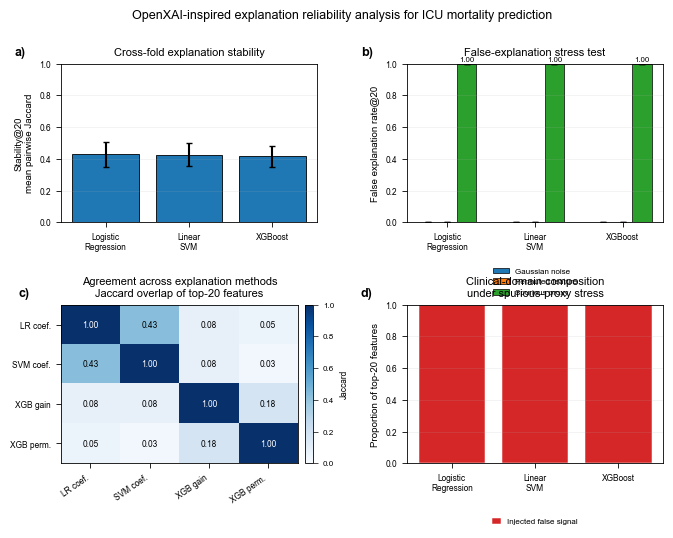

In [10]:
# ============================================================
# 3. Main Figure 4 from saved results
# ============================================================

fig_w = FIG_WIDTH_MM / 25.4
fig_h = MAIN_FIG_HEIGHT_MM / 25.4

fig = plt.figure(figsize=(fig_w, fig_h))
gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=[1, 1],
    height_ratios=[1, 1],
    wspace=0.35,
    hspace=0.52,
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])

x = np.arange(len(plot_models))

# ----------------------------
# a) Stability
# ----------------------------
stab_vals = [
    safe_get_value(stability_df, "model", m, "stability_mean")
    for m in plot_models
]
stab_err = [
    safe_get_value(stability_df, "model", m, "stability_std", default=0)
    for m in plot_models
]

axA.bar(x, stab_vals, yerr=stab_err, capsize=2.5, linewidth=0.6, edgecolor="black")
axA.set_xticks(x)
axA.set_xticklabels(plot_model_labels)
axA.set_ylim(0, 1)
axA.set_ylabel(f"Stability@{TOP_K}\nmean pairwise Jaccard")
axA.set_title("Cross-fold explanation stability")
axA.grid(axis="y", alpha=0.25, linewidth=0.4)
panel_label(axA, "a)")
format_axes(axA)


# ----------------------------
# b) Grouped false-explanation stress test
# ----------------------------
bar_width = 0.22 if len(stress_order) >= 3 else 0.28
offsets = np.linspace(
    -bar_width * (len(stress_order) - 1) / 2,
    bar_width * (len(stress_order) - 1) / 2,
    len(stress_order),
)

max_fer = 0.0

for offset, stress_type in zip(offsets, stress_order):
    vals = []
    errs = []

    for model in plot_models:
        sub = fer_summary_df[
            (fer_summary_df["model"] == model)
            & (fer_summary_df["stress_type"] == stress_type)
        ]

        if len(sub) == 0:
            vals.append(0.0)
            errs.append(0.0)
        else:
            vals.append(float(sub["fer_mean"].iloc[0]))
            errs.append(float(0.0 if pd.isna(sub["fer_std"].iloc[0]) else sub["fer_std"].iloc[0]))

    max_fer = max(max_fer, max(vals) if vals else 0.0)

    axB.bar(
        x + offset,
        vals,
        width=bar_width,
        yerr=errs,
        capsize=2.0,
        linewidth=0.5,
        edgecolor="black",
        label=stress_type,
    )

    for xi, val in zip(x + offset, vals):
        if val > 0:
            axB.text(xi, val + 0.01, f"{val:.2f}", ha="center", va="bottom", fontsize=5.6)

axB.set_xticks(x)
axB.set_xticklabels(plot_model_labels)
axB.set_ylim(0, max(0.25, min(1.0, max_fer + 0.15)))
axB.set_ylabel(f"False explanation rate@{TOP_K}")
axB.set_title("False-explanation stress test")
axB.grid(axis="y", alpha=0.25, linewidth=0.4)
axB.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.24),
    ncol=1,
    frameon=False,
)
panel_label(axB, "b)")
format_axes(axB)


# ----------------------------
# c) Agreement heatmap
# ----------------------------
im = axC.imshow(agreement_mat.values, vmin=0, vmax=1, aspect="auto", cmap="Blues")
methods = list(agreement_mat.index)

axC.set_xticks(np.arange(len(methods)))
axC.set_yticks(np.arange(len(methods)))
axC.set_xticklabels(methods, rotation=35, ha="right")
axC.set_yticklabels(methods)
axC.set_title(f"Agreement across explanation methods\nJaccard overlap of top-{TOP_K} features")

for i in range(len(methods)):
    for j in range(len(methods)):
        val = agreement_mat.values[i, j]
        text_color = "white" if val > 0.55 else "black"
        axC.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=text_color)

cbar = fig.colorbar(im, ax=axC, fraction=0.046, pad=0.03)
cbar.ax.tick_params(labelsize=5.8, width=0.5)
cbar.set_label("Jaccard", fontsize=6)
panel_label(axC, "c)")
format_axes(axC)


# ----------------------------
# d) Domain composition under spurious-proxy stress if available
# ----------------------------
if "Spurious proxy" in domain_summary_df["stress_type"].unique():
    domain_for_plot = domain_summary_df[domain_summary_df["stress_type"] == "Spurious proxy"].copy()
    domain_title = "Clinical-domain composition\nunder spurious-proxy stress"
else:
    domain_for_plot = domain_summary_df.copy()
    domain_title = "Clinical-domain composition\nof explanations"

domain_pivot = (
    domain_for_plot.pivot_table(
        index="model",
        columns="domain",
        values="proportion",
        aggfunc="mean",
    )
    .reindex(plot_models)
    .fillna(0)
)

for domain in domain_order:
    if domain not in domain_pivot.columns:
        domain_pivot[domain] = 0

domain_pivot = domain_pivot[domain_order]

bottom = np.zeros(len(plot_models))

for domain in domain_order:
    vals = domain_pivot[domain].values
    if np.all(vals == 0):
        continue

    axD.bar(
        x,
        vals,
        bottom=bottom,
        label=domain,
        color=domain_colors.get(domain, "0.7"),
        edgecolor="white",
        linewidth=0.35,
    )
    bottom += vals

axD.set_xticks(x)
axD.set_xticklabels(plot_model_labels)
axD.set_ylim(0, 1)
axD.set_ylabel(f"Proportion of top-{TOP_K} features")
axD.set_title(domain_title)
axD.grid(axis="y", alpha=0.25, linewidth=0.4)
axD.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=False,
    handlelength=1.1,
    columnspacing=0.8,
)
panel_label(axD, "d)")
format_axes(axD)


fig.suptitle(
    "OpenXAI-inspired explanation reliability analysis for ICU mortality prediction",
    fontsize=9,
    y=0.995,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.90,
    bottom=0.20,
)

fig.savefig(MAIN_PNG, dpi=600, bbox_inches="tight")
fig.savefig(MAIN_PDF, bbox_inches="tight")

print("Saved main figure:")
print(MAIN_PNG)
print(MAIN_PDF)
plt.show()


In [11]:
# ============================================================
# 4. Build supplementary feature-support and domain tables
# ============================================================

support_df = method_top_features_df.copy()

rank_summary = (
    support_df.groupby("feature", as_index=False)
    .agg(
        n_methods=("method", "nunique"),
        best_rank=("rank", "min"),
        domain=("domain", lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0]),
    )
)

rank_summary = rank_summary.sort_values(
    ["n_methods", "best_rank"],
    ascending=[False, True],
)

selected_features = rank_summary.loc[rank_summary["n_methods"] >= 2, "feature"].tolist()
if len(selected_features) < 8:
    selected_features = rank_summary.head(25)["feature"].tolist()
else:
    selected_features = selected_features[:25]

support_matrix = (
    support_df.assign(present=1)
    .pivot_table(index="feature", columns="method", values="present", aggfunc="max", fill_value=0)
)

method_order = [
    m for m in ["LR coef.", "SVM coef.", "XGB gain", "XGB SHAP", "XGB perm."]
    if m in support_matrix.columns
]

support_matrix = support_matrix.reindex(selected_features).fillna(0)
support_matrix = support_matrix[method_order]

rank_matrix = (
    support_df.pivot_table(index="feature", columns="method", values="rank", aggfunc="min")
    .reindex(selected_features)
)

method_domain = (
    method_top_features_df
    .groupby(["method", "domain"])
    .size()
    .reset_index(name="count")
)

method_domain["proportion"] = method_domain["count"] / TOP_K

method_domain_pivot = (
    method_domain.pivot(index="method", columns="domain", values="proportion")
    .fillna(0)
)

for domain in domain_order:
    if domain not in method_domain_pivot.columns:
        method_domain_pivot[domain] = 0

method_domain_pivot = method_domain_pivot.reindex(method_order).fillna(0)
method_domain_pivot = method_domain_pivot[domain_order]

display(rank_summary.head(20))
display(support_matrix.head(20))
display(method_domain_pivot)


,feature,n_methods,best_rank,domain
13,GCS_last,3,1,Neurological
27,PaCO2_count,3,6,Measurement process
44,Urine_mean,3,8,Renal
49,WBC_mean,2,1,Hematologic
52,pH_median,2,1,Metabolic / acid-base
0,BUN_last,2,2,Renal
48,WBC_max,2,2,Hematologic
54,static_Age,2,2,Static / demographic
17,GCS_std,2,3,Neurological
37,Platelets_min,2,3,Hematologic


method,LR coef.,SVM coef.,XGB gain,XGB perm.
feature,,,,
GCS_last,1,0,1,1
PaCO2_count,1,1,1,0
Urine_mean,1,1,0,1
WBC_mean,1,1,0,0
pH_median,1,1,0,0
BUN_last,1,0,1,0
WBC_max,1,1,0,0
static_Age,0,0,1,1
GCS_std,0,0,1,1


domain,Renal,Cardiovascular,Respiratory,Metabolic / acid-base,Hematologic,Neurological,Static / demographic,Measurement process,Injected false signal,Other clinical
method,,,,,,,,,,
LR coef.,0.20,0.15,0.00,0.1,0.20,0.10,0.0,0.20,0,0.05
SVM coef.,0.20,0.05,0.00,0.2,0.15,0.00,0.0,0.40,0,0.00
XGB gain,0.30,0.00,0.20,0.1,0.00,0.20,0.1,0.10,0,0.00
XGB perm.,0.35,0.05,0.05,0.1,0.05,0.15,0.1,0.15,0,0.00


Saved supplementary figure:
..\figures\Supplementary_Figures\Supplementary_FigureS4_explanation_reliability_diagnostics_170mm.png
..\figures\Supplementary_Figures\Supplementary_FigureS4_explanation_reliability_diagnostics_170mm.pdf


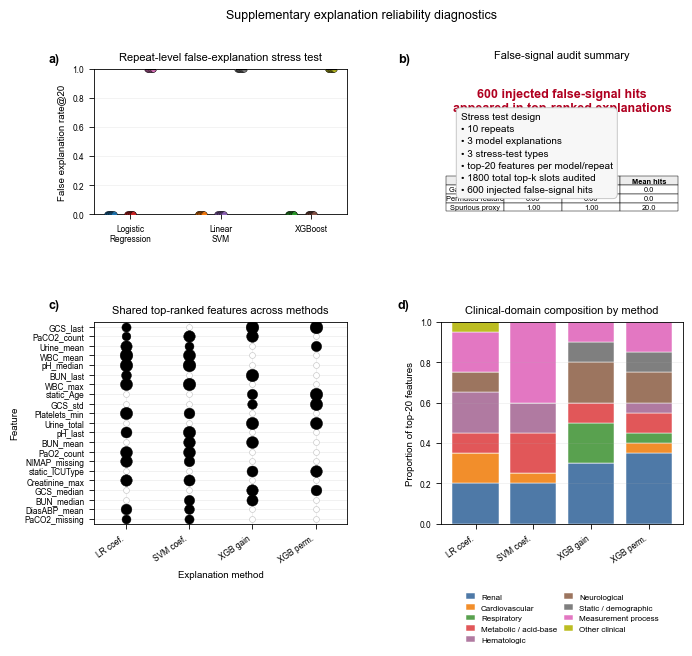

In [12]:
# ============================================================
# 5. Supplementary Figure S4 from saved results
# ============================================================

fig_w = FIG_WIDTH_MM / 25.4
fig_h = SUPP_FIG_HEIGHT_MM / 25.4

fig = plt.figure(figsize=(fig_w, fig_h))
gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=[1.05, 1.0],
    height_ratios=[0.9, 1.25],
    wspace=0.38,
    hspace=0.62,
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])


# ----------------------------
# a) Repeat-level FER by stress type
# ----------------------------
x = np.arange(len(plot_models))
bar_width = 0.22 if len(stress_order) >= 3 else 0.28
offsets = np.linspace(
    -bar_width * (len(stress_order) - 1) / 2,
    bar_width * (len(stress_order) - 1) / 2,
    len(stress_order),
)

max_fer = float(fer_repeats_df["false_explanation_rate"].max())

for offset, stress_type in zip(offsets, stress_order):
    for i, model in enumerate(plot_models):
        vals = fer_repeats_df.loc[
            (fer_repeats_df["model"] == model)
            & (fer_repeats_df["stress_type"] == stress_type),
            "false_explanation_rate",
        ].values

        if len(vals) == 0:
            continue

        jitter = np.linspace(-0.035, 0.035, len(vals)) if len(vals) > 1 else np.array([0])
        axA.scatter(
            np.full(len(vals), i + offset) + jitter,
            vals,
            s=16,
            edgecolor="black",
            linewidth=0.3,
            zorder=3,
        )

        axA.plot(
            [i + offset - 0.055, i + offset + 0.055],
            [np.mean(vals), np.mean(vals)],
            color="black",
            linewidth=0.9,
            zorder=4,
        )

axA.set_xticks(x)
axA.set_xticklabels(plot_model_labels)
axA.set_ylabel(f"False explanation rate@{TOP_K}")
axA.set_title("Repeat-level false-explanation stress test")

if max_fer == 0:
    axA.set_ylim(-0.002, 0.05)
    axA.text(
        0.5,
        0.86,
        "All stress-test repeats produced FER = 0",
        transform=axA.transAxes,
        ha="center",
        va="center",
        fontsize=7,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.75", lw=0.5),
    )
else:
    axA.set_ylim(0, min(1.0, max_fer + 0.08))

axA.grid(axis="y", alpha=0.25, linewidth=0.4)
panel_label(axA, "a)")
format_axes(axA)


# ----------------------------
# b) Stress-test summary table/text
# ----------------------------
axB.axis("off")
panel_label(axB, "b)")
axB.set_title("False-signal audit summary", pad=8)

total_topk_slots = len(fer_repeats_df) * TOP_K
total_false_hits = int(fer_repeats_df["n_injected_false_signals_in_top_k"].sum())
total_repeats = int(fer_repeats_df["repeat"].nunique())
n_models = int(fer_repeats_df["model"].nunique())
n_stress = int(fer_repeats_df["stress_type"].nunique())

if total_false_hits == 0:
    headline = "No injected false signals entered\nthe top-ranked explanations"
    headline_color = "#2E7D32"
else:
    headline = f"{total_false_hits} injected false-signal hits\nappeared in top-ranked explanations"
    headline_color = "#B00020"

axB.text(
    0.5,
    0.78,
    headline,
    ha="center",
    va="center",
    fontsize=9,
    fontweight="bold",
    color=headline_color,
)

summary_text = (
    f"Stress test design\n"
    f"• {total_repeats} repeats\n"
    f"• {n_models} model explanations\n"
    f"• {n_stress} stress-test types\n"
    f"• top-{TOP_K} features per model/repeat\n"
    f"• {total_topk_slots} total top-k slots audited\n"
    f"• {total_false_hits} injected false-signal hits"
)

axB.text(
    0.08,
    0.42,
    summary_text,
    ha="left",
    va="center",
    fontsize=7.2,
    linespacing=1.45,
    bbox=dict(boxstyle="round,pad=0.45", fc="#F7F7F7", ec="0.75", lw=0.6),
)

summary_table = (
    fer_summary_df.groupby("stress_type", as_index=False)
    .agg(
        mean_FER=("fer_mean", "mean"),
        max_FER=("fer_mean", "max"),
        mean_hits=("mean_noise_count", "mean"),
    )
)

summary_table["mean_FER"] = summary_table["mean_FER"].map(lambda x: f"{x:.2f}")
summary_table["max_FER"] = summary_table["max_FER"].map(lambda x: f"{x:.2f}")
summary_table["mean_hits"] = summary_table["mean_hits"].map(lambda x: f"{x:.1f}")

tbl = axB.table(
    cellText=summary_table[["stress_type", "mean_FER", "max_FER", "mean_hits"]].values.tolist(),
    colLabels=["Stress test", "Mean FER", "Max FER", "Mean hits"],
    cellLoc="center",
    colLoc="center",
    bbox=[0.02, 0.02, 0.96, 0.24],
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(5.4)

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0.35)
    if key[0] == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#EDEDED")


# ----------------------------
# c) Shared top-ranked feature dot matrix
# ----------------------------
features = list(support_matrix.index)
features_display = [f if len(f) <= 24 else f[:21] + "..." for f in features]

axC.set_title("Shared top-ranked features across methods")
axC.set_xlim(-0.5, len(method_order) - 0.5)
axC.set_ylim(-0.5, len(features) - 0.5)

for y, feature in enumerate(features):
    for x_i, method in enumerate(method_order):
        present = int(support_matrix.loc[feature, method])

        if present == 1:
            rank_val = rank_matrix.loc[feature, method] if method in rank_matrix.columns else np.nan
            if pd.notna(rank_val):
                size = 85 - 2.3 * min(rank_val, TOP_K)
                size = max(size, 35)
            else:
                size = 55

            axC.scatter(
                x_i,
                y,
                s=size,
                color="black",
                edgecolor="black",
                linewidth=0.3,
                zorder=3,
            )
        else:
            axC.scatter(
                x_i,
                y,
                s=18,
                facecolor="white",
                edgecolor="0.78",
                linewidth=0.45,
                zorder=2,
            )

axC.set_xticks(np.arange(len(method_order)))
axC.set_xticklabels(method_order, rotation=35, ha="right")
axC.set_yticks(np.arange(len(features)))
axC.set_yticklabels(features_display)
axC.invert_yaxis()
axC.set_xlabel("Explanation method")
axC.set_ylabel("Feature")

for x_i in np.arange(len(method_order)):
    axC.axvline(x_i, color="0.92", lw=0.5, zorder=0)

for y in np.arange(len(features)):
    axC.axhline(y, color="0.92", lw=0.5, zorder=0)

panel_label(axC, "c)")
format_axes(axC)


# ----------------------------
# d) Domain composition by explanation method
# ----------------------------
x_methods = np.arange(len(method_order))
bottom = np.zeros(len(method_order))

for domain in domain_order:
    vals = method_domain_pivot[domain].values

    if np.all(vals == 0):
        continue

    axD.bar(
        x_methods,
        vals,
        bottom=bottom,
        label=domain,
        color=domain_colors.get(domain, "0.7"),
        edgecolor="white",
        linewidth=0.35,
    )
    bottom += vals

axD.set_title("Clinical-domain composition by method")
axD.set_xticks(x_methods)
axD.set_xticklabels(method_order, rotation=35, ha="right")
axD.set_ylim(0, 1)
axD.set_ylabel(f"Proportion of top-{TOP_K} features")
axD.grid(axis="y", alpha=0.25, linewidth=0.4)
axD.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.31),
    ncol=2,
    frameon=False,
    handlelength=1.1,
    columnspacing=0.8,
)
panel_label(axD, "d)")
format_axes(axD)


fig.suptitle(
    "Supplementary explanation reliability diagnostics",
    fontsize=9,
    y=0.992,
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.90,
    bottom=0.20,
)

fig.savefig(SUPP_PNG, dpi=600, bbox_inches="tight")
fig.savefig(SUPP_PDF, bbox_inches="tight")

print("Saved supplementary figure:")
print(SUPP_PNG)
print(SUPP_PDF)
plt.show()


## Figure legend drafts

**Main Figure 4. OpenXAI-inspired explanation reliability analysis for ICU mortality prediction.**  
**a)** Cross-fold explanation stability measured as mean pairwise Jaccard similarity among top-20 features across five cross-validation folds.  
**b)** False explanation stress test using Gaussian noise, permuted-feature controls, and train-only spurious proxy features. False explanation rate was defined as the proportion of injected false-signal features appearing among the top-20 explanation features.  
**c)** Agreement across explanation methods, measured as top-20 Jaccard overlap among logistic regression coefficients, linear SVM coefficients, XGBoost gain importance, and XGBoost permutation importance.  
**d)** Clinical-domain composition of top-ranked explanation features under the spurious-proxy stress test.

**Supplementary Figure S4. Detailed explanation reliability diagnostics.**  
**a)** Repeat-level false explanation rates across stress-test types.  
**b)** Summary of total audited top-k slots and injected false-signal hits.  
**c)** Dot matrix showing shared top-ranked features across explanation methods; filled dots indicate feature inclusion and larger dots indicate higher rank.  
**d)** Clinical-domain composition of top-ranked features by explanation method.
